Necessary packages

In [1]:
import tensorflow as tf
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from src.model import build_model
import random

2026-03-11 01:23:42.284082: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 01:23:42.293553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-11 01:23:42.303979: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-11 01:23:42.307225: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-11 01:23:42.315349: I tensorflow/core/platform/cpu_feature_guar

Transformations

In [2]:
#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X[..., tf.newaxis]
test_X = test_X[..., tf.newaxis]

Output

X_train: (60000, 28, 28, 1)
X_test:  (10000, 28, 28, 1)


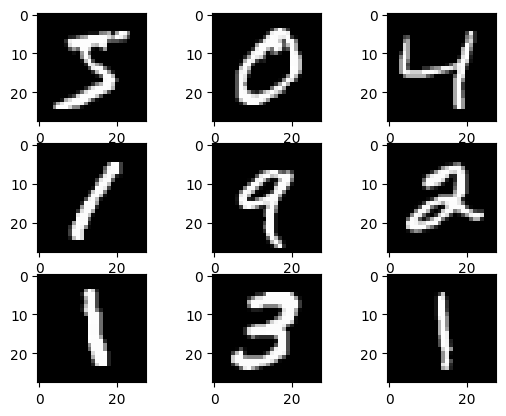

In [3]:
#printing the shapes of the vectors 
print('X_train: ' + str(train_X.shape))
print('X_test:  '  + str(test_X.shape))

#Displaying the n first digits in the datset
for i in range(9):
  plt.subplot(330 + 1 + i) #rows col pos
  plt.imshow(train_X[i], cmap=plt.get_cmap('gray'))
plt.show()

Parameters:

In [10]:
filters_val = [16,32,64,128,256]
learning_rate= random.uniform(0.0005, 0.0015)
batch_size= random.choice(filters_val)
layers = random.choice([1,2,3])

filters = []
for i in range(layers):
    filters.append(random.choice(filters_val))

print(filters, learning_rate, batch_size)

[64, 64] 0.0011007057959455107 16


In [11]:
model = build_model(filters, learning_rate)

In [12]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 64)        640       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 14, 14, 64)        36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0   

In [21]:
model.fit(x=train_X, y=train_y, batch_size=batch_size, epochs=12, validation_split=0.1, verbose=1)

Epoch 1/12
3375/3375 [==============================] - 14s 4ms/step - loss: 0.0675 - accuracy: 0.9830 - val_loss: 0.0837 - val_accuracy: 0.9890
Epoch 2/12
3375/3375 [==============================] - 11s 3ms/step - loss: 0.0714 - accuracy: 0.9822 - val_loss: 0.0662 - val_accuracy: 0.9882
Epoch 3/12
3375/3375 [==============================] - 11s 3ms/step - loss: 0.0710 - accuracy: 0.9828 - val_loss: 0.0648 - val_accuracy: 0.9898
Epoch 4/12
3375/3375 [==============================] - 14s 4ms/step - loss: 0.0709 - accuracy: 0.9831 - val_loss: 0.0901 - val_accuracy: 0.9887
Epoch 5/12
3375/3375 [==============================] - 11s 3ms/step - loss: 0.0647 - accuracy: 0.9835 - val_loss: 0.0675 - val_accuracy: 0.9888
Epoch 6/12
3375/3375 [==============================] - 11s 3ms/step - loss: 0.0721 - accuracy: 0.9831 - val_loss: 0.0771 - val_accuracy: 0.9888
Epoch 7/12
3375/3375 [==============================] - 15s 4ms/step - loss: 0.0650 - accuracy: 0.9854 - val_loss: 0.0599 - val_ac

In [15]:
model.evaluate(x=test_X,y=test_y)

313/313 [==============================] - 1s 2ms/step - loss: 0.0491 - accuracy: 0.9879


[0.049107931554317474, 0.9879000186920166]

1/1 [==============================] - 0s 13ms/step
9


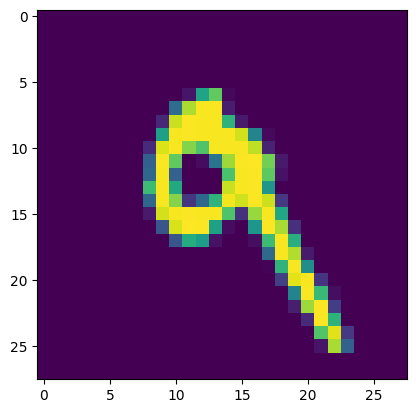

In [20]:
print(np.argmax(model.predict(np.array([test_X[7]]))))
plt.imshow(test_X[7])